  Indexed 12asA00: L=327, 11100 frames, seq=AYIAKQRQISFVKSXFSRQL...
  Indexed 153lA00: L=185, 11140 frames, seq=RTDCYGNVNRIDTTGASCKT...
  Indexed 16pkA02: L=208, 11110 frames, seq=YFAKVLGNPPRPLVAIVGGA...
  Indexed 1a02F00: L=53, 10980 frames, seq=RRIRRERNKMAAAKSRNRRR...
  Indexed 1a05A00: L=357, 11000 frames, seq=MKKIAIFAGDGIGPEIVAAA...
  Indexed 1a0aA00: L=63, 10990 frames, seq=MKRESXKXAEQARRNRLAVA...
  Indexed 1a0hA01: L=89, 11030 frames, seq=SPLLETCVPDRGREYRGRLA...
  Indexed 1a0rP01: L=129, 11010 frames, seq=CMQDMXQKLSFGPRYGFVYE...
  Indexed 1a0sP00: L=413, 10970 frames, seq=SGFEFXGYARSGVIMNDSGA...
  Indexed 1a15A00: L=67, 11090 frames, seq=KPVSLSYRCPCRFFESXVAR...
  Indexed 1a1zA00: L=83, 11040 frames, seq=MDPFLVLLXSVSSSLSSSEL...
  Indexed 1a2nA02: L=208, 11060 frames, seq=AKNAALPILFAALLAEEPVE...
  Indexed 1a39A00: L=401, 10981 frames, seq=KPGETKEVXPQLTTFRCTKR...
  Indexed 1a3dA00: L=119, 11070 frames, seq=NLYQFKNMIKCTVPSRSWWD...
  Indexed 1a3oA00: L=141, 11070 frames, seq=VLSPADKTN

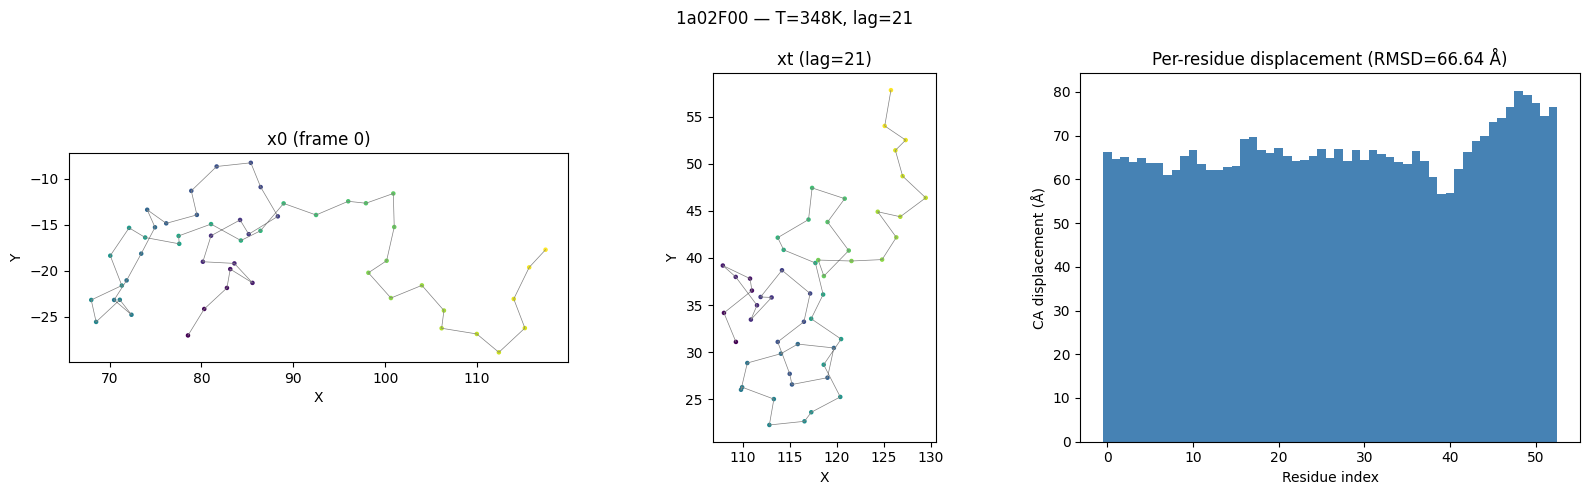

In [3]:

from mini_latent_pd.data import MDCathToMinifoldDataset
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import h5py
import torch

LOCAL_DIR = Path("../data/mdcath")
ds_pair = MDCathToMinifoldDataset(data_dir=LOCAL_DIR / "data", samples_per_epoch=10, max_seq_len=900)

if len(ds_pair.proteins) > 0:
    sample = ds_pair[0]
    x0 = sample["x0"].numpy()   # (L, 37, 3)
    xt = sample["xt"].numpy()   # (L, 37, 3)
    
    # CA coords (slot 1)
    ca_x0 = x0[:, 1, :]
    ca_xt = xt[:, 1, :]
    
    # Per-residue CA displacement
    ca_disp = np.linalg.norm(ca_xt - ca_x0, axis=1)
    
    print(f"=== Frame-pair sample ===")
    print(f"  protein: {sample['id']}")
    print(f"  temp: {sample['temp']} K,  lag: {sample['lag']} frames")
    print(f"  x0 shape: {x0.shape},  xt shape: {xt.shape}")
    print(f"  CA RMSD:  {np.sqrt((ca_disp**2).mean()):.2f} Å")
    print(f"  max CA displacement: {ca_disp.max():.2f} Å")
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # x0 CA trace
    axes[0].plot(ca_x0[:, 0], ca_x0[:, 1], '-', lw=0.5, c="gray")
    axes[0].scatter(ca_x0[:, 0], ca_x0[:, 1], c=np.arange(len(ca_x0)), cmap="viridis", s=5)
    axes[0].set_title("x0 (frame 0)"); axes[0].set_aspect("equal")
    axes[0].set_xlabel("X"); axes[0].set_ylabel("Y")
    
    # xt CA trace
    axes[1].plot(ca_xt[:, 0], ca_xt[:, 1], '-', lw=0.5, c="gray")
    axes[1].scatter(ca_xt[:, 0], ca_xt[:, 1], c=np.arange(len(ca_xt)), cmap="viridis", s=5)
    axes[1].set_title(f"xt (lag={sample['lag']})"); axes[1].set_aspect("equal")
    axes[1].set_xlabel("X"); axes[1].set_ylabel("Y")
    
    # Per-residue displacement
    axes[2].bar(range(len(ca_disp)), ca_disp, color="steelblue", width=1.0)
    axes[2].set_xlabel("Residue index")
    axes[2].set_ylabel("CA displacement (Å)")
    axes[2].set_title(f"Per-residue displacement (RMSD={np.sqrt((ca_disp**2).mean()):.2f} Å)")
    
    plt.suptitle(f"{sample['id']} — T={sample['temp']}K, lag={sample['lag']}", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No proteins found — check LOCAL_DIR")

In [19]:
import torch
import torch.nn.functional as F
from pathlib import Path
import h5py
from mini_latent_pd.models.minifold.model.model import MiniFoldModel
from mini_latent_pd.models.minifold.data.config import model_config
from mini_latent_pd.models.minifold.data.of_data import of_inference
from mini_latent_pd.models.minifold.utils.residue_constants import restype_order_with_x_inverse
from esm.pretrained import load_model_and_alphabet

def load_minifold_model(cache_dir="./minifold_cache", model_size="48L", device="cuda"):
    """
    Loads the MiniFold model, alphabet, and config for interactive use.
    """
    # 1. Paths
    cache = Path(cache_dir).expanduser()
    checkpoint_path = cache / f"minifold_{model_size}.ckpt"
    
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint not found at {checkpoint_path}. Run predict.py once to download it.")

    print(f"Loading checkpoint from {checkpoint_path}...")
    
    # 2. Load Checkpoint & Hyperparams
    ckpt = torch.load(checkpoint_path, map_location="cpu")
    hparams = ckpt["hyper_parameters"]
    
    # 3. Initialize Model
    # We create the config required for feature generation
    config_of = model_config(
        "initial_training",
        train=False,
        low_prec=False,
        long_sequence_inference=False,
    )
    
    model = MiniFoldModel(
        esm_model_name=hparams["esm_model_name"],
        num_blocks=hparams["num_blocks"],
        no_bins=hparams["no_bins"],
        config_of=config_of,
        use_structure_module=True,
        kernels=False, # Important: False for Mac/MPS compatibility
    )

    # 4. Load State Dict
    state_dict = ckpt["state_dict"]
    # Clean keys as done in predict.py
    state_dict = {k: v for k, v in state_dict.items() if "boundaries" not in k}
    state_dict = {k: v for k, v in state_dict.items() if "mid_points" not in k}
    state_dict = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}
    state_dict = {k.replace("model.", ""): v for k, v in state_dict.items()}
    
    model.load_state_dict(state_dict, strict=False)
    model.to(device)
    model.eval()
    
    # 5. Load Alphabet (needed for tokenizing sequences)
    _, alphabet = load_model_and_alphabet(hparams["esm_model_name"])
    
    return model, alphabet, config_of.data

# 1. Setup Device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Load Model
# Ensure you point cache_dir to where predict.py downloaded weights
model, alphabet, config = load_minifold_model(cache_dir="/Users/moustholmes/mini_latent_pd/checkpoints/minifold_cache", model_size="12L", device=device)

Using device: mps
Loading checkpoint from /Users/moustholmes/mini_latent_pd/checkpoints/minifold_cache/minifold_12L.ckpt...


In [12]:
x0.shape

torch.Size([1, 83, 37, 3])

In [11]:
## Step 2: Run MiniFold on a batch from our dataset to see its prediction format
# The model needs: batch["seq"] (tokenized), batch["mask"]
# If use_structure_module: also needs batch["batch_of"] with OpenFold features

from mini_latent_pd.models.minifold.utils import residue_constants as rc

# Build the "seq" tokens that ESM expects from our sequence string
sample = ds_pair[0]
sequence = sample["sequence"]
L = len(sequence)

print(sample["x0"].shape)  # (L, 37, 3)
print(sequence)

# ESM tokenization: <cls> + sequence + <eos>
batch_converter = alphabet.get_batch_converter()
data = [("protein", sequence)]
_, _, tokens = batch_converter(data)  # tokens: (1, L+2)

# The MiniFold forward expects batch["seq"] and batch["mask"]
# mask is 1 for real positions, 0 for padding. ESM tokens include <cls> and <eos>,
# so mask should cover (L+2) positions — but MiniFold expects mask over the ESM token dim.
mask = torch.ones(1, tokens.shape[1], dtype=torch.float32)

minifold_batch = {
    "seq": tokens.to(device),
    "mask": mask.to(device),
}

# Run the model (without structure module first — just get distogram preds and pair repr)
# The model already loaded from cell 2 has use_structure_module=True,
# but we won't pass batch_of features (needed by StructureModule), so let's
# temporarily disable it to just get the distogram + pair outputs
orig_use_sm = model.use_structure_module
model.use_structure_module = False

with torch.no_grad():
    out = model(minifold_batch, num_recycling=0)

model.use_structure_module = orig_use_sm

print("=== MiniFold output keys ===")
for k, v in out.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k:25s}  {str(tuple(v.shape)):25s}  {v.dtype}")

preds = out["preds"]    # distogram logits
s_z_out = out["pair"]   # pair representation after miniformer

print(f"\n=== Distogram prediction (preds) ===")
print(f"  shape: {preds.shape}")    # (1, L+2, L+2, 64)
print(f"  is logits (not one-hot): min={preds.min():.3f}, max={preds.max():.3f}")
print(f"  argmax distribution:")
bin_counts = preds[0].argmax(-1).flatten().bincount(minlength=64)
top5 = bin_counts.argsort(descending=True)[:5]
for b in top5:
    print(f"    bin {b.item()}: {bin_counts[b].item()} pairs")

print(f"\n=== Pair representation (s_z after MiniFormer) ===")
print(f"  shape: {s_z_out.shape}")   # (1, L+2, L+2, 128)
print(f"  stats: mean={s_z_out.mean():.4f}, std={s_z_out.std():.4f}")

# Check: the recycled dists would be one_hot(argmax(preds), 64)
recycled_dists = F.one_hot(preds.argmax(dim=-1), 64).float()
print(f"\n=== What recycle would see (one-hot of predicted bins) ===")
print(f"  shape: {recycled_dists.shape}")
print(f"  sum per pair: {recycled_dists.sum(dim=-1).unique()}")


torch.Size([83, 37, 3])
MDPFLVLLXSVSSSLSSSELTELKGLCLGRVGKRKLERVQSGLDLFSMLLEQNDLEPGXTELLRELLASLRRXDLLRRVDDFE
=== MiniFold output keys ===
  preds                      (1, 85, 85, 64)            torch.float32
  pair                       (1, 85, 85, 128)           torch.float32

=== Distogram prediction (preds) ===
  shape: torch.Size([1, 85, 85, 64])
  is logits (not one-hot): min=-710.485, max=324.454
  argmax distribution:
    bin 63: 522 pairs
    bin 34: 208 pairs
    bin 28: 206 pairs
    bin 33: 194 pairs
    bin 37: 190 pairs

=== Pair representation (s_z after MiniFormer) ===
  shape: torch.Size([1, 85, 85, 128])
  stats: mean=6.1078, std=59.0336

=== What recycle would see (one-hot of predicted bins) ===
  shape: torch.Size([1, 85, 85, 64])
  sum per pair: tensor([1.], device='mps:0')


In [9]:
len(sequence)
#check sequence for number of X residues (non-standard amino acids) which are tokenized as <unk> by ESM and may cause issues for MiniFold since it was trained on standard residues.
print(f"Number of residues: {len(sequence)}")
num_x = sequence.count("X")
print(f"Number of 'X' residues (non-standard): {num_x}")

Number of residues: 185
Number of 'X' residues (non-standard): 5


## Prototyping: coords → distogram → recycle format

The FoldingTrunk uses `dists` as input to `recycle = nn.Linear(64, 128)`:
1. Takes atom37 coords → extract **pseudo-Cβ** (Cβ for all, Cα for Gly)
2. Compute **pairwise squared distances**
3. **Bin** into 64 bins using `linspace(2.3125, 21.6875, 63) ** 2` as boundaries
4. **One-hot encode** → shape `(B, L, L, 64)`

This is exactly the same binning used in `distogram_loss` and `pts_to_distogram`.

After the MiniFormer, `preds` are **logits** of shape `(B, L, L, 64)`, symmetrized via `fc_out(s_z_c + s_z_c.T)`. For the next recycling step these logits are converted back to one-hot via `argmax → one_hot`.

So: our "informed" dists (from real coords) should be in the **same one-hot format** as what the recycling loop uses.

In [ ]:
tokens,

NameError: name 'tokens' is not defined

In [14]:
## Step 1: Build coords_to_distogram — same binning as FoldingTrunk / distogram_loss

import torch
import torch.nn.functional as F
from mini_latent_pd.models.minifold.utils import residue_constants as rc

def pseudo_beta_from_atom37(atom37_pos, aatype):
    """
    Extract pseudo-Cβ positions: Cβ for all residues, Cα for Glycine.
    
    Args:
        atom37_pos: (*, L, 37, 3) — all-atom positions in Å
        aatype: (*, L) — residue type indices
    Returns:
        pseudo_beta: (*, L, 3) — Cβ (or Cα for Gly) positions
    """
    ca_idx = rc.atom_order["CA"]  # 1
    cb_idx = rc.atom_order["CB"]  # 3
    is_gly = (aatype == rc.restype_order["G"])  # Gly has no Cβ
    
    # Expand mask for 3D coords: (*, L) → (*, L, 3)
    is_gly_3d = is_gly.unsqueeze(-1).expand_as(atom37_pos[..., ca_idx, :])
    
    pseudo_beta = torch.where(
        is_gly_3d,
        atom37_pos[..., ca_idx, :],
        atom37_pos[..., cb_idx, :],
    )
    return pseudo_beta


def coords_to_distogram(atom37_pos, aatype, min_bin=2.3125, max_bin=21.6875, no_bins=64):
    """
    Convert atom37 coordinates to one-hot distogram matching FoldingTrunk's recycle format.
    
    Args:
        atom37_pos: (B, L, 37, 3) — all-atom positions in Å
        aatype: (B, L) — residue type indices
        min_bin, max_bin: distance bin edges in Å (matching distogram_loss defaults)
        no_bins: number of bins (64 to match MiniFold's disto_bins)
    Returns:
        dists_onehot: (B, L, L, no_bins) — one-hot encoded binned distances
    """
    # Extract pseudo-Cβ positions
    pseudo_beta = pseudo_beta_from_atom37(atom37_pos, aatype)  # (B, L, 3)
    
    # Compute squared pairwise distances (same approach as distogram_loss)
    # pseudo_beta: (B, L, 3) → (B, L, 1, 3) - (B, 1, L, 3) → (B, L, L)
    sq_dists = torch.sum(
        (pseudo_beta.unsqueeze(-2) - pseudo_beta.unsqueeze(-3)) ** 2,
        dim=-1,
    )  # (B, L, L)
    
    # Bin boundaries: linspace in Å, then squared (matches distogram_loss L509-511)
    boundaries = torch.linspace(min_bin, max_bin, no_bins - 1, device=atom37_pos.device)
    boundaries = boundaries ** 2
    
    # Count how many boundaries each distance exceeds → bin index
    bin_indices = torch.sum(sq_dists.unsqueeze(-1) > boundaries, dim=-1)  # (B, L, L)
    
    # One-hot encode (same as the recycling step in FoldingTrunk)
    dists_onehot = F.one_hot(bin_indices.long(), no_bins).to(atom37_pos.dtype)
    
    return dists_onehot


# ── Test it on a sample ──
sample = ds_pair[0]
x0 = sample["x0"].unsqueeze(0)       # (1, L, 37, 3)
aatype = sample["aatype"].unsqueeze(0)  # (1, L)

dgram = coords_to_distogram(x0, aatype)
print(f"x0 shape:       {x0.shape}")
print(f"aatype shape:    {aatype.shape}")
print(f"distogram shape: {dgram.shape}")  # expect (1, L, L, 64)
print(f"sum per pair (should be 1.0 everywhere): {dgram.sum(dim=-1).unique()}")
print(f"bin index range: [{dgram.argmax(-1).min()}, {dgram.argmax(-1).max()}]")

# Also check with pts_to_distogram for consistency
from mini_latent_pd.models.minifold.utils.tensor_utils import pts_to_distogram
pseudo_beta = pseudo_beta_from_atom37(x0, aatype)
bin_idx_ref = pts_to_distogram(pseudo_beta)  # uses torch.bucketize → indices
bin_idx_ours = dgram.argmax(dim=-1)

match = (bin_idx_ref == bin_idx_ours).float().mean()
print(f"\nConsistency with pts_to_distogram: {match:.4f} (should be 1.0)")


x0 shape:       torch.Size([1, 119, 37, 3])
aatype shape:    torch.Size([1, 119])
distogram shape: torch.Size([1, 119, 119, 64])
sum per pair (should be 1.0 everywhere): tensor([1.])
bin index range: [0, 63]

Consistency with pts_to_distogram: 1.0000 (should be 1.0)


## Step 3: Prototype the full Encode path

**Encoding pipeline:**
1. **ESM forward** → `s_s (B, L+2, 1024)`, `s_z (B, L+2, L+2, 128)` — includes cls/eos tokens
2. **s_z_static** = `projection(cat([s_z, seq_to_pair(s_s), rel_pos(residx, mask)]))` — shape `(B, L+2, L+2, 128)`
3. **distogram** from real coords: `coords_to_distogram(atom37, aatype)` → `(B, L, L, 64)`, then **pad** to `(B, L+2, L+2, 64)` for cls/eos
4. **z** = `s_z_static + recycle(distogram)` — our latent representation `(B, L+2, L+2, 128)`

**Verifying the encode:**
- `preds = fc_out(z + z.T)` → distogram logits `(B, L+2, L+2, 64)`
- The argmax of preds (at residue positions `[1:-1, 1:-1]`) should match the ground-truth distogram from step 3

In [16]:
## Encode: coords → z (latent pair representation)

# ── 0. Get a consistent sample & tokenize ──
sample = ds_pair[0]
sequence = sample["sequence"]
L_res = len(sequence)

batch_converter = alphabet.get_batch_converter()
_, _, tokens = batch_converter([("protein", sequence)])
tokens = tokens.to(device)
mask = torch.ones(1, tokens.shape[1], dtype=torch.float32, device=device)
B, N = 1, tokens.shape[1]

print(f"Protein: {sample['id']}, L={L_res}, N={N} (L+2)")

# ── 1. ESM forward → s_s, s_z ──
model.eval()
with torch.no_grad():
    idx = model.lm.num_layers
    lm_out = model.lm(tokens, repr_layers=[idx], need_head_weights=True)
    s_s_esm = model.fc_s(lm_out["representations"][idx])  # (1, N, 1024)
    s_z_esm = model.fc_z(lm_out["attentions"].view(B, N, N, -1))  # (1, N, N, 128)

print(f"ESM s_s: {s_s_esm.shape}, s_z: {s_z_esm.shape}")

# ── 2. Compute s_z_static using FoldingTrunk components ──
fold = model.fold
pair_mask = mask[:, None, :] * mask[:, :, None]
residx = torch.arange(N, device=device).unsqueeze(0).expand(B, -1)

with torch.no_grad():
    s_z_cat = torch.cat([
        s_z_esm,
        fold.seq_to_pair(s_s_esm),
        fold.positional_embedding(residx, mask=pair_mask),
    ], dim=-1)  # (1, N, N, 128*3)
    s_z_static = fold.projection(s_z_cat)  # (1, N, N, 128)

print(f"s_z_static: {s_z_static.shape}")

# ── 3. Distogram from real coords, pad to (N, N, 64) ──
x0_tensor = sample["x0"].unsqueeze(0).to(device)  # (1, L, 37, 3)
aatype_tensor = sample["aatype"].unsqueeze(0).to(device)  # (1, L)

dgram_res = coords_to_distogram(x0_tensor, aatype_tensor)  # (1, L, L, 64)

# Pad to (1, N, N, 64): zeros for cls (pos 0) and eos (pos L+1)
dgram_padded = torch.zeros(B, N, N, 64, device=device, dtype=dgram_res.dtype)
dgram_padded[:, 1:L_res+1, 1:L_res+1, :] = dgram_res

print(f"distogram (residues): {dgram_res.shape}")
print(f"distogram (padded):   {dgram_padded.shape}")

# ── 4. z = s_z_static + recycle(distogram) ──
with torch.no_grad():
    z = s_z_static + fold.recycle(dgram_padded)  # (1, N, N, 128)

print(f"\n=== Encoded z (latent pair representation) ===")
print(f"  shape: {z.shape}")
print(f"  stats: mean={z.mean():.4f}, std={z.std():.4f}")

# ── 5. Verify: decode z → distogram via fc_out ──
with torch.no_grad():
    preds_from_z = fold.fc_out(z + z.transpose(1, 2))  # (1, N, N, 64)

# Compare ground truth vs decoded predictions (residue positions only)
dgram_gt_bins = dgram_res.argmax(dim=-1)        # (1, L, L)
dgram_pred_bins = preds_from_z[:, 1:L_res+1, 1:L_res+1, :].argmax(dim=-1)

match_rate = (dgram_gt_bins == dgram_pred_bins).float().mean()
mae_bins = (dgram_gt_bins - dgram_pred_bins).float().abs().mean()

print(f"\n=== Decode verification (z → distogram via fc_out, NO MiniFormer) ===")
print(f"  bin exact-match rate: {match_rate:.4f}")
print(f"  bin MAE: {mae_bins:.2f}")

# ── 6. Run MiniFormer on z to refine, then decode ──
with torch.no_grad():
    z_refined = fold.miniformer(z, pair_mask)  # (1, N, N, 128)
    preds_refined = fold.fc_out(z_refined + z_refined.transpose(1, 2))

dgram_refined_bins = preds_refined[:, 1:L_res+1, 1:L_res+1, :].argmax(dim=-1)
match_refined = (dgram_gt_bins == dgram_refined_bins).float().mean()
mae_refined = (dgram_gt_bins - dgram_refined_bins).float().abs().mean()

print(f"\n=== After MiniFormer refinement ===")
print(f"  bin exact-match rate: {match_refined:.4f}")
print(f"  bin MAE: {mae_refined:.2f}")

# ── 7. Compare with baseline: uninformed z (dists=zeros, like normal MiniFold) ──
with torch.no_grad():
    z_uninformed = s_z_static + fold.recycle(torch.zeros_like(dgram_padded))
    z_uninformed_ref = fold.miniformer(z_uninformed, pair_mask)
    preds_uninformed = fold.fc_out(z_uninformed_ref + z_uninformed_ref.transpose(1, 2))

dgram_uninf_bins = preds_uninformed[:, 1:L_res+1, 1:L_res+1, :].argmax(dim=-1)
match_uninf = (dgram_gt_bins == dgram_uninf_bins).float().mean()
mae_uninf = (dgram_gt_bins - dgram_uninf_bins).float().abs().mean()

print(f"\n=== Baseline: UNINFORMED (dists=zeros) + MiniFormer ===")
print(f"  bin exact-match rate: {match_uninf:.4f}")
print(f"  bin MAE: {mae_uninf:.2f}")
print(f"\n→ Informed encoding should beat uninformed since it directly encodes the ground-truth structure.")

Protein: 1a0sP00, L=413, N=415 (L+2)
ESM s_s: torch.Size([1, 415, 1024]), s_z: torch.Size([1, 415, 415, 128])
s_z_static: torch.Size([1, 415, 415, 128])
distogram (residues): torch.Size([1, 413, 413, 64])
distogram (padded):   torch.Size([1, 415, 415, 64])

=== Encoded z (latent pair representation) ===
  shape: torch.Size([1, 415, 415, 128])
  stats: mean=-0.1197, std=10.0042

=== Decode verification (z → distogram via fc_out, NO MiniFormer) ===
  bin exact-match rate: 0.0029
  bin MAE: 57.45

=== After MiniFormer refinement ===
  bin exact-match rate: 0.7151
  bin MAE: 4.67

=== Baseline: UNINFORMED (dists=zeros) + MiniFormer ===
  bin exact-match rate: 0.6187
  bin MAE: 6.36

→ Informed encoding should beat uninformed since it directly encodes the ground-truth structure.


## Step 4: Decode latent z → atom37 via StructureModule

**Decode pipeline:**
1. **PairToSequence** projects `z_refined (B, N, N, 128)` + `s_s (B, N, 1024)` → single repr `s (B, N, 1024)`
2. **Slice** to residue positions `[1:-1]` (strip ESM cls/eos tokens)
3. **StructureModule** takes `(s, z, aatype, mask)` → atom14 positions `(B, L, 14, 3)`
4. **atom14_to_atom37** maps to full representation `(B, L, 37, 3)`
5. **Compare** predicted atom37 vs ground-truth from the dataset

We need `make_atom14_masks` from the data transforms to build the atom14↔atom37 index mappings from `aatype`.

In [17]:
## Decode: z → atom37 via StructureModule
# Uses kernel variables from Step 3: z_refined, s_s_esm, pair_mask, sample, L_res, N, device

from mini_latent_pd.models.minifold.data.data_transforms import make_atom14_masks
from mini_latent_pd.models.minifold.utils.feats import atom14_to_atom37

# ── 1. PairToSequence: z_refined → single repr ──
with torch.no_grad():
    single = model.sz_project(z_refined, s_s_esm, pair_mask)  # (1, N, 1024) — ESM token space

print(f"single repr: {single.shape}")

# ── 2. Slice to residue space [1:-1] — strip cls/eos ──
s_res = single[:, 1:L_res+1, :]              # (1, L, 1024)
z_res = z_refined[:, 1:L_res+1, 1:L_res+1, :]  # (1, L, L, 128)
mask_res = torch.ones(1, L_res, dtype=torch.float32, device=device)

# aatype in residue space
aatype_dev = sample["aatype"].unsqueeze(0).to(device).long()  # (1, L)

print(f"Residue sliced — s: {s_res.shape}, z: {z_res.shape}, aatype: {aatype_dev.shape}")

# ── 3. Build atom14 ↔ atom37 index mappings from aatype ──
feats = {"aatype": aatype_dev.squeeze(0)}  # make_atom14_masks expects unbatched or will index directly
feats = make_atom14_masks(feats)
# Re-batch: expand all mask tensors to (1, L, ...)
feats_batched = {k: v.unsqueeze(0) if v.dim() == 1 else v.unsqueeze(0) for k, v in feats.items()}

print(f"atom14_atom_exists: {feats_batched['atom14_atom_exists'].shape}")
print(f"atom37_atom_exists: {feats_batched['atom37_atom_exists'].shape}")
print(f"residx_atom37_to_atom14: {feats_batched['residx_atom37_to_atom14'].shape}")

# ── 4. Run StructureModule ──
with torch.no_grad():
    sm_out = model.structure_module(
        s=s_res,
        z=z_res,
        aatype=aatype_dev,
        mask=mask_res,
    )

# StructureModule outputs atom14 positions: (num_blocks, B, L, 14, 3)
pred_atom14 = sm_out["positions"][-1]  # last block: (1, L, 14, 3)
print(f"\nStructureModule atom14 output: {pred_atom14.shape}")

# ── 5. Convert atom14 → atom37 ──
pred_atom37 = atom14_to_atom37(pred_atom14, feats_batched)  # (1, L, 37, 3)
atom37_mask = feats_batched["atom37_atom_exists"]  # (1, L, 37)

print(f"pred_atom37: {pred_atom37.shape}")
print(f"atom37_mask sum per residue (avg): {atom37_mask.sum(-1).mean():.1f} atoms")

# ── 6. Compare with ground-truth atom37 ──
gt_atom37 = sample["x0"].unsqueeze(0).to(device)  # (1, L, 37, 3)
gt_mask = sample["atom37_mask"].unsqueeze(0).to(device)  # (1, L, 37)

# Use the intersection of predicted and GT atom masks
valid_mask = (atom37_mask * gt_mask).bool()  # (1, L, 37)
n_valid = valid_mask.sum().item()

# Per-atom coordinate error
diff = (pred_atom37 - gt_atom37)[valid_mask]  # (n_valid, 3)
per_atom_dist = diff.norm(dim=-1)  # (n_valid,)

print(f"\n=== Atom37 reconstruction quality ===")
print(f"  Valid atoms compared: {n_valid}")
print(f"  Per-atom RMSD: {per_atom_dist.pow(2).mean().sqrt():.2f} Å")
print(f"  Per-atom MAE:  {per_atom_dist.mean():.2f} Å")
print(f"  Median error:  {per_atom_dist.median():.2f} Å")

# ── 7. Cα-only comparison ──
CA_IDX = 1  # atom37 index for Cα
ca_pred = pred_atom37[:, :, CA_IDX, :]  # (1, L, 3)
ca_gt = gt_atom37[:, :, CA_IDX, :]      # (1, L, 3)

# Superpose (Kabsch alignment) for a fair RMSD comparison
def kabsch_rmsd(P, Q):
    """Kabsch-aligned RMSD between two point clouds (N, 3)."""
    P_c = P - P.mean(0)
    Q_c = Q - Q.mean(0)
    H = P_c.T @ Q_c
    U, S, Vt = torch.linalg.svd(H)
    d = torch.det(Vt.T @ U.T)
    sign = torch.diag(torch.tensor([1, 1, d.sign()], device=P.device, dtype=P.dtype))
    R = Vt.T @ sign @ U.T
    P_aligned = P_c @ R.T
    return (P_aligned - Q_c).pow(2).sum(-1).mean().sqrt()

ca_rmsd_raw = (ca_pred[0] - ca_gt[0]).pow(2).sum(-1).mean().sqrt()
ca_rmsd_aligned = kabsch_rmsd(ca_pred[0], ca_gt[0])

print(f"\n=== Cα RMSD ===")
print(f"  Raw (no alignment):    {ca_rmsd_raw:.2f} Å")
print(f"  Kabsch-aligned:        {ca_rmsd_aligned:.2f} Å")

# ── 8. Also compare uninformed baseline (what MiniFold predicts without coords) ──
with torch.no_grad():
    single_uninf = model.sz_project(z_uninformed_ref, s_s_esm, pair_mask)
    s_uninf_res = single_uninf[:, 1:L_res+1, :]
    z_uninf_res = z_uninformed_ref[:, 1:L_res+1, 1:L_res+1, :]
    sm_uninf = model.structure_module(s=s_uninf_res, z=z_uninf_res, aatype=aatype_dev, mask=mask_res)
    pred_uninf_atom14 = sm_uninf["positions"][-1]
    pred_uninf_atom37 = atom14_to_atom37(pred_uninf_atom14, feats_batched)

ca_uninf = pred_uninf_atom37[:, :, CA_IDX, :]
ca_rmsd_uninf = kabsch_rmsd(ca_uninf[0], ca_gt[0])

print(f"\n=== Baseline: UNINFORMED (no coords info) ===")
print(f"  Cα Kabsch-aligned RMSD: {ca_rmsd_uninf:.2f} Å")
print(f"\n→ Informed encoding should have LOWER RMSD (structure info helps reconstruction)")

single repr: torch.Size([1, 415, 1024])
Residue sliced — s: torch.Size([1, 413, 1024]), z: torch.Size([1, 413, 413, 128]), aatype: torch.Size([1, 413])
atom14_atom_exists: torch.Size([1, 413, 14])
atom37_atom_exists: torch.Size([1, 413, 37])
residx_atom37_to_atom14: torch.Size([1, 413, 37])

StructureModule atom14 output: torch.Size([1, 413, 14, 3])


/Users/moustholmes/mini_latent_pd/src/mini_latent_pd/models/minifold/utils/tensor_utils.py:86: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:312.)
  return data[ranges]


pred_atom37: torch.Size([1, 413, 37, 3])
atom37_mask sum per residue (avg): 7.6 atoms

=== Atom37 reconstruction quality ===
  Valid atoms compared: 3131
  Per-atom RMSD: 85.98 Å
  Per-atom MAE:  84.86 Å
  Median error:  84.29 Å


/var/folders/s2/8rc4lm651yq7h79nm3jxjzmm0000gn/T/ipykernel_84907/897015703.py:82: UserWarning: The operator 'aten::linalg_svd' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:15.)
  U, S, Vt = torch.linalg.svd(H)



=== Cα RMSD ===
  Raw (no alignment):    86.03 Å
  Kabsch-aligned:        18.95 Å

=== Baseline: UNINFORMED (no coords info) ===
  Cα Kabsch-aligned RMSD: 19.71 Å

→ Informed encoding should have LOWER RMSD (structure info helps reconstruction)


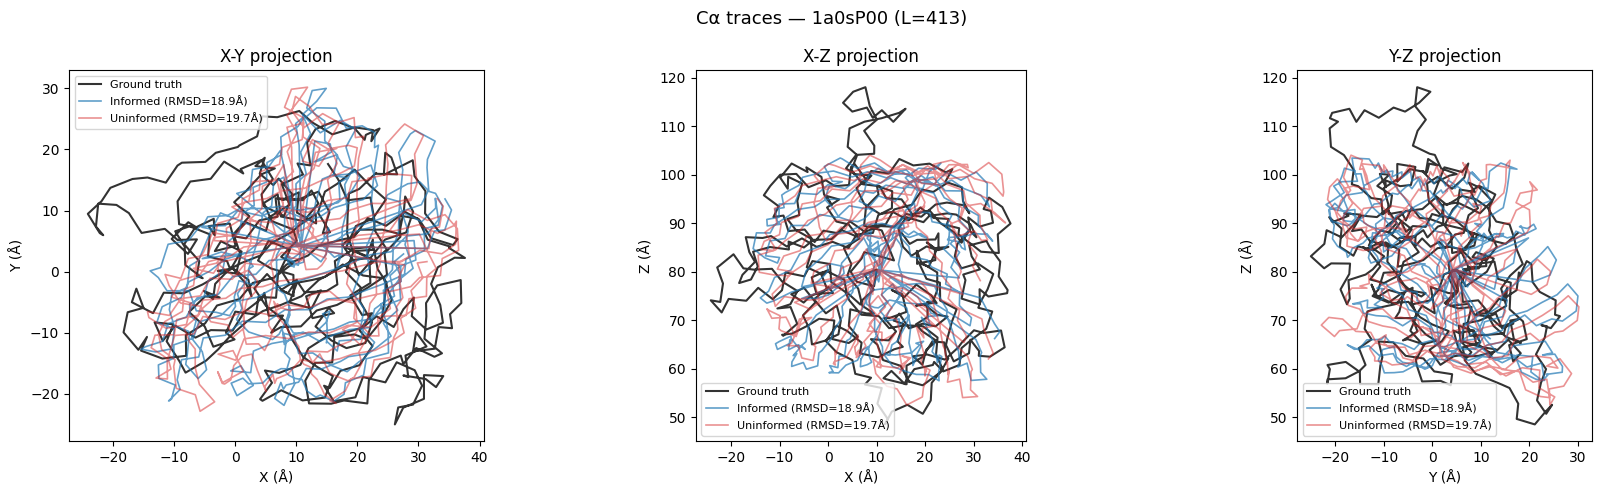

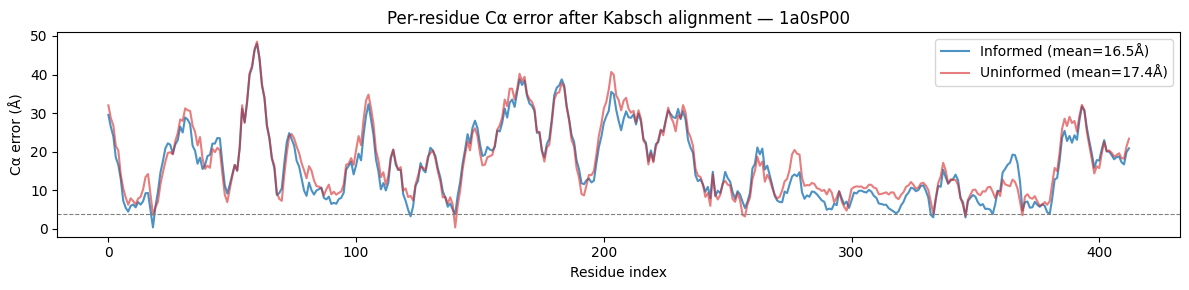

In [18]:
## Visualise: Cα traces — ground truth vs informed decode vs uninformed decode

import matplotlib.pyplot as plt
import numpy as np

def kabsch_align(P, Q):
    """Align P onto Q via Kabsch, return aligned P (numpy)."""
    Pc = P - P.mean(0)
    Qc = Q - Q.mean(0)
    H = Pc.T @ Qc
    U, S, Vt = np.linalg.svd(H)
    d = np.linalg.det(Vt.T @ U.T)
    sign = np.diag([1, 1, np.sign(d)])
    R = Vt.T @ sign @ U.T
    return Pc @ R.T + Q.mean(0)

ca_gt_np = ca_gt[0].cpu().numpy()
ca_inf_np = kabsch_align(ca_pred[0].cpu().numpy(), ca_gt_np)
ca_uninf_np = kabsch_align(ca_uninf[0].cpu().numpy(), ca_gt_np)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2D projections (X-Y, X-Z, Y-Z)
projections = [("X", "Y", 0, 1), ("X", "Z", 0, 2), ("Y", "Z", 1, 2)]
for ax, (xlabel, ylabel, i, j) in zip(axes, projections):
    ax.plot(ca_gt_np[:, i], ca_gt_np[:, j], '-', color='black', lw=1.5, label='Ground truth', alpha=0.8)
    ax.plot(ca_inf_np[:, i], ca_inf_np[:, j], '-', color='tab:blue', lw=1.2, label=f'Informed (RMSD={ca_rmsd_aligned:.1f}Å)', alpha=0.7)
    ax.plot(ca_uninf_np[:, i], ca_uninf_np[:, j], '-', color='tab:red', lw=1.2, label=f'Uninformed (RMSD={ca_rmsd_uninf:.1f}Å)', alpha=0.5)
    ax.set_xlabel(f'{xlabel} (Å)')
    ax.set_ylabel(f'{ylabel} (Å)')
    ax.legend(fontsize=8)
    ax.set_aspect('equal')
    ax.set_title(f'{xlabel}-{ylabel} projection')

fig.suptitle(f'Cα traces — {sample["id"]} (L={L_res})', fontsize=13)
plt.tight_layout()
plt.show()

# Per-residue Cα error plot
ca_err_inf = np.linalg.norm(ca_inf_np - ca_gt_np, axis=-1)
ca_err_uninf = np.linalg.norm(ca_uninf_np - ca_gt_np, axis=-1)

fig2, ax2 = plt.subplots(figsize=(12, 3))
ax2.plot(ca_err_inf, label=f'Informed (mean={ca_err_inf.mean():.1f}Å)', color='tab:blue', alpha=0.8)
ax2.plot(ca_err_uninf, label=f'Uninformed (mean={ca_err_uninf.mean():.1f}Å)', color='tab:red', alpha=0.6)
ax2.set_xlabel('Residue index')
ax2.set_ylabel('Cα error (Å)')
ax2.set_title(f'Per-residue Cα error after Kabsch alignment — {sample["id"]}')
ax2.legend()
ax2.axhline(y=3.8, color='grey', ls='--', lw=0.8, label='peptide bond length')
plt.tight_layout()
plt.show()

## Collator: batching and padding

Since proteins have different lengths, we need to:
1. **Pad** all tensors in a batch to the max length (zero-padding)
2. **Create a `seq_mask`** so the model knows which positions are real vs padding

**Smart batching** (`BucketBatchSampler`): groups proteins of similar length into the same batch. This minimises wasted padding — a batch of [60, 62, 58] residue proteins needs almost no padding, while a naive batch of [60, 200, 500] wastes ~80% of compute on padding zeros.

The implementation:
- `mdcath_collate`: pads all residue-length tensor dims to max_len, stacks scalars, creates `seq_mask`
- `BucketBatchSampler`: assigns proteins to length buckets, samples batches within each bucket, then shuffles batch order

In [4]:
## Test the collator
from mini_latent_pd.data import mdcath_collate, BucketBatchSampler
from torch.utils.data import DataLoader

# Grab a few samples to test collation
samples = [ds_pair[i] for i in range(min(4, len(ds_pair)))]
print("Individual sample shapes:")
for i, s in enumerate(samples):
    L = s["aatype"].shape[0]
    print(f"  sample {i}: id={s['id']}, L={L}")

batch = mdcath_collate(samples)

print(f"\n=== Collated batch ===")
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k:25s}  {str(tuple(v.shape)):20s}  {v.dtype}")
    else:
        print(f"  {k:25s}  {type(v).__name__}: {v}")

print(f"\n  seq_mask sum per sample: {batch['seq_mask'].sum(dim=1).tolist()}")
print(f"  (should match individual L values above)")

Individual sample shapes:
  sample 0: id=16pkA02, L=208
  sample 1: id=1a66A00, L=178
  sample 2: id=1a0aA00, L=63
  sample 3: id=153lA00, L=185

=== Collated batch ===
  id                         list: ['16pkA02', '1a66A00', '1a0aA00', '153lA00']
  x0                         (4, 208, 37, 3)       torch.float32
  xt                         (4, 208, 37, 3)       torch.float32
  lag                        list: [125, 103, 82, 81]
  temp                       list: [413, 379, 450, 379]
  sequence                   list: ['YFAKVLGNPPRPLVAIVGGAKVSDKIQLLDNMLQRIDYLLIGGAMAYTFLKAQGYSIGKSKCEESKLEFARSLLKKAEDRKVQVILPIDXVCXTEFKAVDSPLITEDQNIPEGXMALDIGPKTIEKYVQTIGKCKSAIWNGPMGVFEMVPYSKGTFAIAKAMGRGTXEXGLMSIIGGGDSASAAELSGEAKRMSXVSTGGGASLELLE', 'MKDWQLPSXSGPYELRIEVQPKSXXRARYETEGSRGAVKASAGGXPIVQLXGYLENEPLMLQLFIGTADDRLLRPXAFYQVXRITGKTVSTTSXEAILSNTKVLEIPLLPENSMRAVIDCAGILKLRNSDIELRKGETDIGRKNTRVRLVFRVXVPQPSGRTLSLQVASNPIECSQRS', 'MKRESXKXAEQARRNRLAVALXELASLIPAEWKQQNVSAAPSKATTVEAACRYIRXLQQNGST', 'RTDCYGNVNRIDT

In [5]:
## Test BucketBatchSampler — smart batching

# Get lengths for all proteins in the dataset
lengths = [p["n_residues"] for p in ds_pair.proteins]
print(f"=== Dataset protein lengths ===")
print(f"  proteins: {len(lengths)}")
print(f"  length range: [{min(lengths)}, {max(lengths)}]")
print(f"  lengths: {sorted(lengths)}")

# Create bucket sampler
sampler = BucketBatchSampler(
    lengths=lengths,
    batch_size=2,
    shuffle=True,
)

print(f"\n=== BucketBatchSampler ===")
print(f"  bucket_limits: {sampler.bucket_limits}")
print(f"  buckets: {[len(b) for b in sampler.buckets]} proteins per bucket")
print(f"  total batches: {len(sampler)}")

print(f"\n  Batches (showing protein indices and their lengths):")
for i, batch_indices in enumerate(sampler):
    batch_lens = [lengths[j] for j in batch_indices]
    padding_waste = max(batch_lens) * len(batch_lens) - sum(batch_lens)
    print(f"    batch {i}: indices={batch_indices}, lengths={batch_lens}, padding_waste={padding_waste}")

# Compare with naive batching
naive_batches = [list(range(i, min(i+2, len(lengths)))) for i in range(0, len(lengths), 2)]
print(f"\n  Naive batching comparison:")
for i, batch_indices in enumerate(naive_batches):
    batch_lens = [lengths[j] for j in batch_indices]
    padding_waste = max(batch_lens) * len(batch_lens) - sum(batch_lens)
    print(f"    batch {i}: lengths={batch_lens}, padding_waste={padding_waste}")

=== Dataset protein lengths ===
  proteins: 18
  length range: [53, 413]
  lengths: [53, 63, 67, 83, 89, 111, 119, 129, 141, 178, 185, 208, 208, 327, 342, 357, 401, 413]

=== BucketBatchSampler ===
  bucket_limits: [67, 119, 178, 327, 413]
  buckets: [3, 4, 3, 4, 4] proteins per bucket
  total batches: 10

  Batches (showing protein indices and their lengths):
    batch 0: indices=[13, 10], lengths=[119, 83], padding_waste=36
    batch 1: indices=[7], lengths=[129], padding_waste=0
    batch 2: indices=[8, 4], lengths=[413, 357], padding_waste=56
    batch 3: indices=[16, 12], lengths=[342, 401], padding_waste=59
    batch 4: indices=[17, 14], lengths=[178, 141], padding_waste=37
    batch 5: indices=[1, 2], lengths=[185, 208], padding_waste=23
    batch 6: indices=[5, 9], lengths=[63, 67], padding_waste=4
    batch 7: indices=[11, 0], lengths=[208, 327], padding_waste=119
    batch 8: indices=[3], lengths=[53], padding_waste=0
    batch 9: indices=[15, 6], lengths=[111, 89], padding_w

In [6]:
## Full DataLoader with smart batching

loader = DataLoader(
    ds_pair,
    batch_sampler=sampler,
    collate_fn=mdcath_collate,
    num_workers=0,
)

print(f"=== DataLoader with BucketBatchSampler ===")
for i, batch in enumerate(loader):
    L_max = batch["x0"].shape[1]
    B = batch["x0"].shape[0]
    real_lens = batch["seq_mask"].sum(dim=1).int().tolist()
    print(f"  batch {i}: B={B}, L_max={L_max}, real_lengths={real_lens}")
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            print(f"    {k:25s}  {str(tuple(v.shape)):20s}  {v.dtype}")
    if i >= 2:
        print(f"  ... ({len(loader)} total batches)")
        break

=== DataLoader with BucketBatchSampler ===
  batch 0: B=2, L_max=401, real_lengths=[327, 401]
    x0                         (2, 401, 37, 3)       torch.float32
    xt                         (2, 401, 37, 3)       torch.float32
    aatype                     (2, 401)              torch.int64
    atom37_mask                (2, 401, 37)          torch.float32
    seq_mask                   (2, 401)              torch.float32
  batch 1: B=2, L_max=208, real_lengths=[185, 208]
    x0                         (2, 208, 37, 3)       torch.float32
    xt                         (2, 208, 37, 3)       torch.float32
    aatype                     (2, 208)              torch.int64
    atom37_mask                (2, 208, 37)          torch.float32
    seq_mask                   (2, 208)              torch.float32
  batch 2: B=2, L_max=327, real_lengths=[327, 185]
    x0                         (2, 327, 37, 3)       torch.float32
    xt                         (2, 327, 37, 3)       torch.float32
    

## Distogram Sensitivity Experiment

**Goal**: Quantify how distogram bin indices change between MD frames and at coordinate-space interpolation points.

- For frame pairs `(x0, xt)`, compute bin indices `d_0` and `d_t`
- Compute `Δd = |d_t - d_0|` for all L×L residue pairs
- Create interpolated coordinates at `t = 0.25, 0.5, 0.75`: `x_interp = (1-t)*x0 + t*xt`
- Convert each to bin indices, compare to `d_0`
- Bar plots: distribution of bin differences (0, 1, 2, ..., max)

**Key question**: Is the 64-bin distogram resolution fine enough to capture MD frame-to-frame dynamics?

  Indexed 12asA00: L=327, 11100 frames, seq=AYIAKQRQISFVKSXFSRQL...
  Indexed 153lA00: L=185, 11140 frames, seq=RTDCYGNVNRIDTTGASCKT...
  Indexed 16pkA02: L=208, 11110 frames, seq=YFAKVLGNPPRPLVAIVGGA...
  Indexed 1a02F00: L=53, 10980 frames, seq=RRIRRERNKMAAAKSRNRRR...
  Indexed 1a05A00: L=357, 11000 frames, seq=MKKIAIFAGDGIGPEIVAAA...
  Indexed 1a0aA00: L=63, 10990 frames, seq=MKRESXKXAEQARRNRLAVA...
  Indexed 1a0hA01: L=89, 11030 frames, seq=SPLLETCVPDRGREYRGRLA...
  Indexed 1a0rP01: L=129, 11010 frames, seq=CMQDMXQKLSFGPRYGFVYE...
  Indexed 1a0sP00: L=413, 10970 frames, seq=SGFEFXGYARSGVIMNDSGA...
  Indexed 1a15A00: L=67, 11090 frames, seq=KPVSLSYRCPCRFFESXVAR...
  Indexed 1a1zA00: L=83, 11040 frames, seq=MDPFLVLLXSVSSSLSSSEL...
  Indexed 1a2nA02: L=208, 11060 frames, seq=AKNAALPILFAALLAEEPVE...
  Indexed 1a39A00: L=401, 10981 frames, seq=KPGETKEVXPQLTTFRCTKR...
  Indexed 1a3dA00: L=119, 11070 frames, seq=NLYQFKNMIKCTVPSRSWWD...
  Indexed 1a3oA00: L=141, 11070 frames, seq=VLSPADKTN

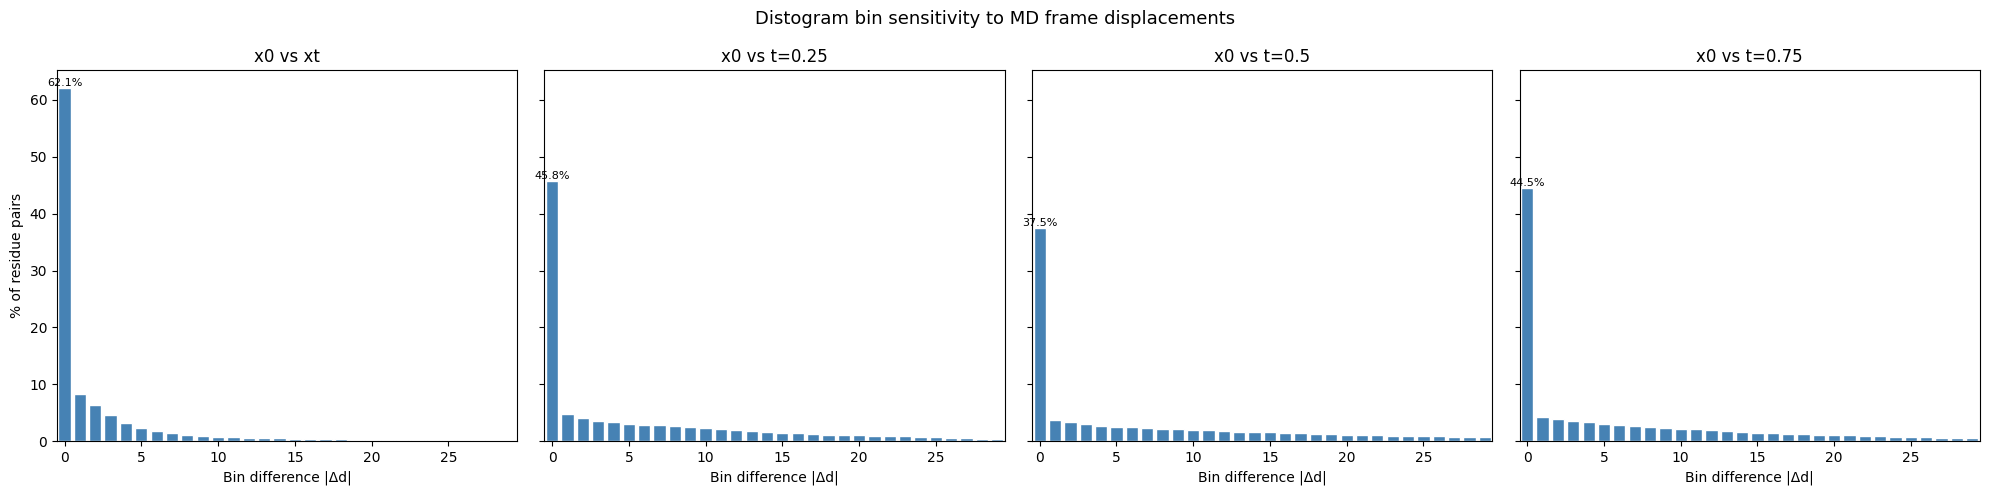

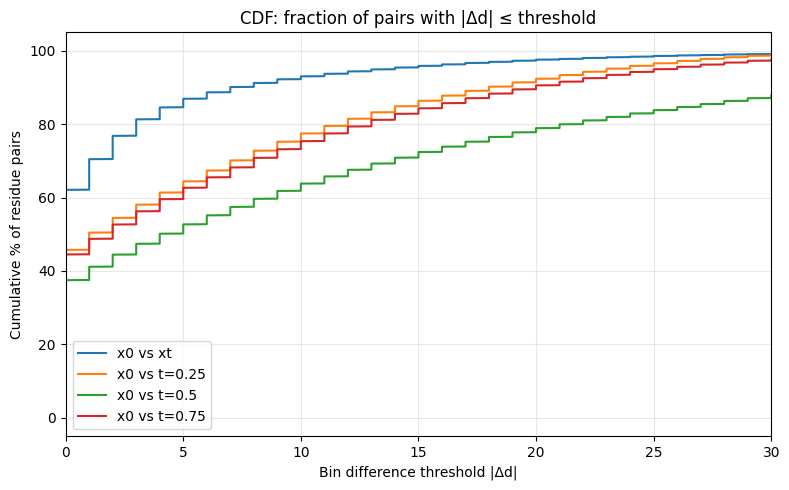

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from mini_latent_pd.data import MDCathToMinifoldDataset
from mini_latent_pd.utils.geometry import pseudo_beta_from_atom37

# ── Config ──
LOCAL_DIR = Path("../data/mdcath")
NUM_SAMPLES = 100  # number of frame pairs to analyze
T_INTERP = [0.25, 0.5, 0.75]
MIN_BIN, MAX_BIN, NO_BINS = 2.3125, 21.6875, 64

# ── Helper: coords → bin indices (without one-hot) ──
def coords_to_bin_indices(atom37_pos, aatype):
    """atom37_pos: (L, 37, 3), aatype: (L,) → bin_indices: (L, L) int"""
    pb = pseudo_beta_from_atom37(atom37_pos.unsqueeze(0), aatype.unsqueeze(0)).squeeze(0)  # (L, 3)
    sq_dists = ((pb.unsqueeze(0) - pb.unsqueeze(1)) ** 2).sum(-1)  # (L, L)
    boundaries = torch.linspace(MIN_BIN, MAX_BIN, NO_BINS - 1) ** 2
    return (sq_dists.unsqueeze(-1) > boundaries).sum(-1).long()  # (L, L)

# ── Load dataset ──
ds = MDCathToMinifoldDataset(data_dir=LOCAL_DIR / "data", samples_per_epoch=NUM_SAMPLES * 5, max_seq_len=900)
print(f"Dataset: {len(ds.proteins)} proteins, sampling {NUM_SAMPLES} frame pairs")

# ── Collect bin-difference distributions ──
all_diffs = {label: [] for label in ["x0 vs xt"] + [f"x0 vs t={t}" for t in T_INTERP]}

for i in range(min(NUM_SAMPLES, len(ds))):
    sample = ds[i]
    x0 = sample["x0"]          # (L, 37, 3)
    xt = sample["xt"]          # (L, 37, 3)
    aatype = sample["aatype"]  # (L,)
    L = x0.shape[0]

    d0 = coords_to_bin_indices(x0, aatype)    # (L, L)
    dt = coords_to_bin_indices(xt, aatype)    # (L, L)

    # Upper-triangle mask (exclude diagonal — self-distances are always 0)
    triu_mask = torch.triu(torch.ones(L, L, dtype=torch.bool), diagonal=1)

    # Source vs Target
    diff_st = (dt - d0).abs()[triu_mask].numpy()
    all_diffs["x0 vs xt"].append(diff_st)

    # Interpolated coordinates at each t
    for t in T_INTERP:
        x_interp = (1.0 - t) * x0 + t * xt  # linear interpolation in coord space
        d_interp = coords_to_bin_indices(x_interp, aatype)
        diff_interp = (d_interp - d0).abs()[triu_mask].numpy()
        all_diffs[f"x0 vs t={t}"].append(diff_interp)

    if i == 0:
        print(f"  Sample 0: {sample['id']}, L={L}, temp={sample['temp']}K, lag={sample['lag']}")
        print(f"    x0 vs xt — mean Δbin: {diff_st.mean():.3f}, max: {diff_st.max()}, "
              f"zero-diff: {(diff_st == 0).mean()*100:.1f}%")

# ── Aggregate ──
for label in all_diffs:
    all_diffs[label] = np.concatenate(all_diffs[label])

# ── Summary table ──
print(f"\n{'Label':<20} {'Mean Δbin':>10} {'Max Δbin':>10} {'Zero-diff %':>12} {'1-bin %':>10} {'≥5 bins %':>10}")
print("-" * 80)
for label, diffs in all_diffs.items():
    print(f"{label:<20} {diffs.mean():>10.3f} {diffs.max():>10d} "
          f"{(diffs == 0).mean()*100:>11.1f}% {(diffs == 1).mean()*100:>9.1f}% "
          f"{(diffs >= 5).mean()*100:>9.1f}%")

# ── Bar plots ──
fig, axes = plt.subplots(1, len(all_diffs), figsize=(5 * len(all_diffs), 5), sharey=True)
if len(all_diffs) == 1:
    axes = [axes]

max_diff_global = max(d.max() for d in all_diffs.values())
bins_range = np.arange(0, min(max_diff_global + 1, 30))  # cap at 30 for readability

for ax, (label, diffs) in zip(axes, all_diffs.items()):
    counts = np.array([(diffs == b).sum() for b in bins_range])
    fracs = counts / len(diffs) * 100
    ax.bar(bins_range, fracs, color="steelblue", edgecolor="white", width=0.8)
    ax.set_xlabel("Bin difference |Δd|")
    ax.set_title(label)
    ax.set_xlim(-0.5, bins_range[-1] + 0.5)
    # Annotate the zero-diff bar
    if fracs[0] > 0:
        ax.annotate(f"{fracs[0]:.1f}%", (0, fracs[0]), ha="center", va="bottom", fontsize=8)

axes[0].set_ylabel("% of residue pairs")
plt.suptitle("Distogram bin sensitivity to MD frame displacements", fontsize=13)
plt.tight_layout()
plt.show()

# ── Cumulative: what fraction of pairs change by ≤ k bins? ──
fig, ax = plt.subplots(figsize=(8, 5))
for label, diffs in all_diffs.items():
    sorted_d = np.sort(diffs)
    cdf = np.arange(1, len(sorted_d) + 1) / len(sorted_d)
    # Subsample for plotting efficiency
    step = max(1, len(sorted_d) // 2000)
    ax.plot(sorted_d[::step], cdf[::step] * 100, label=label, lw=1.5)

ax.set_xlabel("Bin difference threshold |Δd|")
ax.set_ylabel("Cumulative % of residue pairs")
ax.set_title("CDF: fraction of pairs with |Δd| ≤ threshold")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, min(max_diff_global, 30))
plt.tight_layout()
plt.show()